# Notebook 05 — Evaluation Tổng Hợp v3

**4 I-JEPA models:**
- I-JEPA Linear Probe (v1)
- I-JEPA Partial FT v1 (`ijepa_partial_finetune_best.pth`)
- I-JEPA Partial FT v2 (`ijepa_partial_finetune_v2_best.pth`)
- I-JEPA Full FT v1 (`ijepa_full_finetune_resume_best.pth`)
- I-JEPA Full FT v2 (`ijepa_full_finetune_v2_best.pth`)

**Fixes:**
- `read_image()` nhận cả `.dcm` và `.dicom`
- `torch.amp` thay `torch.cuda.amp` (không deprecated)
- `_AMP_DEVICE` định nghĩa toàn cục
- `train_quick()` hỗ trợ ResNet50 (không có `.encoder`)
- `_safe_round()` guard NaN
- VinDr label fix tích hợp sẵn


In [1]:
# ============================================================
# CELL 1: IMPORTS VÀ CẤU HÌNH
# ============================================================
import os, gc, json, math, time, shutil, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, recall_score, precision_score,
    accuracy_score, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

try:
    import timm
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","timm"])
    import timm

try:
    import pydicom
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","pydicom"])
    import pydicom

SEED = 42
def set_seed(s=42):
    import random
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# FIX: định nghĩa toàn cục, dùng cho autocast + GradScaler
_AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

OUTPUT_DIR = Path("/kaggle/working/notebook05_evaluation_v3")
TABLE_DIR  = OUTPUT_DIR / "tables"
FIG_DIR    = OUTPUT_DIR / "figures"
PRED_DIR   = OUTPUT_DIR / "predictions"
for d in [TABLE_DIR, FIG_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INPUT_ROOT   = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")
IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

SESSION_SAFE_SECONDS = 11.5 * 3600
NOTEBOOK_START_TIME  = time.time()
print("Output:", OUTPUT_DIR)


Device: cuda
GPU: Tesla T4
Output: /kaggle/working/notebook05_evaluation_v3


In [2]:
# ============================================================
# CELL 2: TÌM TẤT CẢ INPUT FILES
# ============================================================
def find_file(filename):
    for root in [WORKING_ROOT, INPUT_ROOT]:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    return None

# RSNA CSVs
RSNA_TRAIN_CSV = find_file("rsna_train.csv")
RSNA_VAL_CSV   = find_file("rsna_val.csv")
RSNA_TEST_CSV  = find_file("rsna_test.csv")

# VinDr CSV
VINDR_CSV = (find_file("vindr_external_test_fixed.csv")
             or find_file("vindr_external_test.csv"))

# Encoder NIH
IJEPA_ENCODER_CKPT = find_file("ijepa_vit_small_nih_50k_best_encoder.pth")

# I-JEPA checkpoints — 4 phiên bản
IJEPA_LINEAR_CKPT     = find_file("ijepa_linear_probe_best.pth")
IJEPA_PARTIAL_V1_CKPT = find_file("ijepa_partial_finetune_best.pth")
IJEPA_PARTIAL_V2_CKPT = find_file("ijepa_partial_finetune_v2_best.pth")
IJEPA_FULL_V1_CKPT    = find_file("ijepa_full_finetune_resume_best.pth")
IJEPA_FULL_V2_CKPT    = find_file("ijepa_full_finetune_v2_best.pth")

# Baseline checkpoints
RESNET50_CKPT = find_file("resnet50_imagenet_best.pth")
VIT_CKPT      = find_file("vit_imagenet_best.pth")

print("=== RSNA CSVs ===")
print("Train:", RSNA_TRAIN_CSV)
print("Val  :", RSNA_VAL_CSV)
print("Test :", RSNA_TEST_CSV)
print("\n=== VinDr ===")
print("VinDr CSV:", VINDR_CSV)
print("\n=== I-JEPA Checkpoints ===")
print("Encoder      :", IJEPA_ENCODER_CKPT)
print("Linear       :", IJEPA_LINEAR_CKPT)
print("Partial FT v1:", IJEPA_PARTIAL_V1_CKPT)
print("Partial FT v2:", IJEPA_PARTIAL_V2_CKPT)
print("Full FT v1   :", IJEPA_FULL_V1_CKPT)
print("Full FT v2   :", IJEPA_FULL_V2_CKPT)
print("\n=== Baseline Checkpoints ===")
print("ResNet50:", RESNET50_CKPT)
print("ViT     :", VIT_CKPT)

assert RSNA_TRAIN_CSV and RSNA_VAL_CSV and RSNA_TEST_CSV, "Thiếu RSNA CSVs"
assert IJEPA_ENCODER_CKPT or IJEPA_FULL_V1_CKPT or IJEPA_FULL_V2_CKPT, \
    "Thiếu tất cả I-JEPA checkpoints"


=== RSNA CSVs ===
Train: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_train.csv
Val  : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_val.csv
Test : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_test.csv

=== VinDr ===
VinDr CSV: /kaggle/input/notebooks/nguyentongphuc/05-evaluation-fixed-final/vindr_external_test_fixed.csv

=== I-JEPA Checkpoints ===
Encoder      : /kaggle/input/notebooks/nguyentongphuc/03-i-jepa-pretraining2/notebook03_ijepa_pretrain/checkpoints/ijepa_vit_small_nih_50k_best_encoder.pth
Linear       : /kaggle/input/notebooks/trnhuti666/04-fine-tune-i-jepa-4/notebook04_ijepa_finetune_v2/checkpoints/ijepa_linear_probe_best.pth
Partial FT v1: /kaggle/input/notebooks/nguyentongphuc/04-fine-tune-i-jepa-2/notebook04_ijepa_finetune/checkpoints/ijepa_partial_finetune_best.pth
Partial FT v2: /kaggle/input/notebooks/trnhuti666/04-fine-tune-i-jepa-4/

In [3]:
# ============================================================
# CELL 3: HÀM TIỆN ÍCH DÙNG CHUNG
# ============================================================

def fix_df_paths(df):
    def _fix(p):
        if Path(p).exists():
            return p
        matches = list(INPUT_ROOT.rglob(Path(p).name))
        return str(matches[0]) if matches else None
    df = df.copy()
    df["image_path"] = df["image_path"].apply(_fix)
    return df.dropna(subset=["image_path"]).reset_index(drop=True)

# FIX: nhận cả .dcm và .dicom
def read_image(path):
    p = str(path)
    if p.endswith(".dcm") or p.endswith(".dicom"):
        arr = pydicom.dcmread(p).pixel_array.astype(np.float32)
        mn, mx = arr.min(), arr.max()
        arr = ((arr - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
        return Image.fromarray(arr).convert("RGB")
    return Image.open(p).convert("RGB")

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(7),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class RSNADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_image(row["image_path"])
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(float(row["label"]), dtype=torch.float32)

# ── Model ─────────────────────────────────────────────────
class IJEPAClassifier(nn.Module):
    def __init__(self, encoder, embed_dim=384, dropout=0.2):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )
    def forward(self, x):
        return self.classifier(self.encoder(x)).squeeze(1)

def _load_ijepa_from_ckpt(ckpt_path, dropout=0.2):
    """Load IJEPAClassifier từ bất kỳ checkpoint nào (full state_dict)."""
    enc = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=0)
    model = IJEPAClassifier(enc, embed_dim=enc.num_features, dropout=dropout).to(DEVICE)
    try:    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError: ck = torch.load(ckpt_path, map_location="cpu")
    sd = ck.get("model_state_dict", ck)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    if missing: print(f"  Missing keys: {len(missing)}")
    model.eval()
    print(f"  Loaded: {Path(ckpt_path).name} | "
          f"epoch={ck.get('epoch', ck.get('abs_epoch','?'))} | "
          f"best_auc={ck.get('best_auc','?')}")
    return model

def make_ijepa_linear():
    assert IJEPA_LINEAR_CKPT, "Không tìm thấy linear probe checkpoint"
    print("Loading I-JEPA Linear Probe...")
    return _load_ijepa_from_ckpt(IJEPA_LINEAR_CKPT, dropout=0.2)

def make_ijepa_partial_v1():
    assert IJEPA_PARTIAL_V1_CKPT, "Không tìm thấy Partial FT v1 checkpoint"
    print("Loading I-JEPA Partial FT v1...")
    return _load_ijepa_from_ckpt(IJEPA_PARTIAL_V1_CKPT, dropout=0.2)

def make_ijepa_partial_v2():
    assert IJEPA_PARTIAL_V2_CKPT, "Không tìm thấy Partial FT v2 checkpoint"
    print("Loading I-JEPA Partial FT v2...")
    return _load_ijepa_from_ckpt(IJEPA_PARTIAL_V2_CKPT, dropout=0.3)  # v2 dùng dropout=0.3

def make_ijepa_full_v1():
    assert IJEPA_FULL_V1_CKPT, "Không tìm thấy Full FT v1 checkpoint"
    print("Loading I-JEPA Full FT v1...")
    return _load_ijepa_from_ckpt(IJEPA_FULL_V1_CKPT, dropout=0.2)

def make_ijepa_full_v2():
    assert IJEPA_FULL_V2_CKPT, "Không tìm thấy Full FT v2 checkpoint"
    print("Loading I-JEPA Full FT v2...")
    return _load_ijepa_from_ckpt(IJEPA_FULL_V2_CKPT, dropout=0.3)  # v2 dùng dropout=0.3

# ── Metrics ───────────────────────────────────────────────
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    try:    auc = roc_auc_score(y_true, y_prob)
    except: auc = np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        "threshold":        float(threshold),
        "auc":              float(auc),
        "f1":               float(f1_score(y_true, y_pred, zero_division=0)),
        "recall_pneumonia": float(recall_score(y_true, y_pred, zero_division=0)),
        "precision":        float(precision_score(y_true, y_pred, zero_division=0)),
        "specificity":      float(tn / (tn + fp + 1e-8)),
        "accuracy":         float(accuracy_score(y_true, y_pred)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def find_best_thresholds(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    rows       = [compute_metrics(y_true, y_prob, t) for t in thresholds]
    curve_df   = pd.DataFrame(rows)
    curve_df["youden_j"] = curve_df["recall_pneumonia"] + curve_df["specificity"] - 1
    results = []
    m = compute_metrics(y_true, y_prob, 0.5)
    m["threshold_type"] = "default_0.5"; results.append(m)
    m = curve_df.loc[curve_df["f1"].idxmax()].to_dict()
    m["threshold_type"] = "best_f1"; results.append(m)
    m = curve_df.loc[curve_df["youden_j"].idxmax()].to_dict()
    m["threshold_type"] = "best_youden"; results.append(m)
    for target in [0.80, 0.85, 0.90]:
        cands = curve_df[curve_df["recall_pneumonia"] >= target]
        if len(cands):
            m = cands.loc[cands["f1"].idxmax()].to_dict()
            m["threshold_type"] = f"recall>={target:.2f}"
        else:
            m = curve_df.loc[curve_df["recall_pneumonia"].idxmax()].to_dict()
            m["threshold_type"] = f"recall>={target:.2f}_not_reached"
        results.append(m)
    return pd.DataFrame(results), curve_df

# FIX: _safe_round guard NaN/None
def _safe_round(val, digits=4):
    try:
        v = float(val)
        return None if (v != v) else round(v, digits)  # nan != nan
    except (TypeError, ValueError):
        return None

# FIX: torch.amp (không deprecated)
@torch.no_grad()
def quick_evaluate_auc(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast(_AMP_DEVICE, enabled=torch.cuda.is_available()):
            logits = model(imgs)
        logits = logits.squeeze(-1) if logits.dim() > 1 else logits
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels.extend(labels.numpy())
    return roc_auc_score(np.array(all_labels).astype(int), np.array(all_probs))

print("Utility functions defined ✓")


Utility functions defined ✓


In [4]:
# ============================================================
# CELL 4: ĐỌC RSNA METADATA + TÍNH POS_WEIGHT
# ============================================================
train_df = fix_df_paths(pd.read_csv(RSNA_TRAIN_CSV))
val_df   = fix_df_paths(pd.read_csv(RSNA_VAL_CSV))
test_df  = fix_df_paths(pd.read_csv(RSNA_TEST_CSV))

n_neg      = (train_df["label"] == 0).sum()
n_pos      = (train_df["label"] == 1).sum()
POS_WEIGHT = torch.tensor([n_neg / n_pos], dtype=torch.float32)

print(f"Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print(f"POS_WEIGHT = {POS_WEIGHT.item():.4f}  (neg={n_neg}, pos={n_pos})")


Train 18,678 | Val 4,003 | Test 4,003
POS_WEIGHT = 3.4387  (neg=14470, pos=4208)


In [5]:
# ============================================================
# CELL 5: LOAD PREDICTION CSVs ĐÃ CÓ (NB02 + NB04)
# ============================================================
pred_file_map = {
    "ResNet50 ImageNet":    "resnet50_predictions.csv",
    "ViT-Small ImageNet":   "vit_predictions.csv",
    "I-JEPA Linear Probe":  "ijepa_linear_probe_predictions.csv",
    "I-JEPA Partial FT v1": "ijepa_partial_finetune_predictions.csv",
    "I-JEPA Partial FT v2": "ijepa_partial_finetune_v2_predictions.csv",
    "I-JEPA Full FT v1":    "ijepa_full_ft_resume_predictions.csv",
    "I-JEPA Full FT v2":    "ijepa_full_finetune_v2_predictions.csv",
}

predictions = {}
for model_name, fname in pred_file_map.items():
    p = find_file(fname)
    if p is None:
        print(f"  SKIP (not found): {model_name}")
        continue
    df = pd.read_csv(p)
    df["label"]          = df["label"].astype(int)
    df["prob_pneumonia"] = df["prob_pneumonia"].astype(float)
    predictions[model_name] = df
    auc = roc_auc_score(df["label"], df["prob_pneumonia"])
    print(f"  Loaded {model_name}: {len(df):,} samples | AUC={auc:.4f}")

print(f"\nModels từ CSV: {list(predictions.keys())}")


  Loaded ResNet50 ImageNet: 4,003 samples | AUC=0.8862


  Loaded ViT-Small ImageNet: 4,003 samples | AUC=0.8797


  Loaded I-JEPA Linear Probe: 4,003 samples | AUC=0.7737


  Loaded I-JEPA Partial FT v1: 4,003 samples | AUC=0.8003


  Loaded I-JEPA Partial FT v2: 4,003 samples | AUC=0.8011


  SKIP (not found): I-JEPA Full FT v1


  Loaded I-JEPA Full FT v2: 4,003 samples | AUC=0.8041

Models từ CSV: ['ResNet50 ImageNet', 'ViT-Small ImageNet', 'I-JEPA Linear Probe', 'I-JEPA Partial FT v1', 'I-JEPA Partial FT v2', 'I-JEPA Full FT v2']


In [6]:
# ============================================================
# CELL 6: GENERATE PREDICTIONS CHO CÁC MODEL CHƯA CÓ
# Chạy inference cho: Linear, Partial v1/v2, Full v1/v2
# ============================================================

_test_loader = DataLoader(RSNADataset(test_df, eval_transform),
                          batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

def generate_predictions(model_name, model_fn, csv_name):
    """Chạy inference và lưu predictions nếu chưa có."""
    if model_name in predictions:
        print(f"{model_name}: đã có trong memory ✓")
        return
    ckpt_ok = {
        "I-JEPA Linear Probe":  IJEPA_LINEAR_CKPT,
        "I-JEPA Partial FT v1": IJEPA_PARTIAL_V1_CKPT,
        "I-JEPA Partial FT v2": IJEPA_PARTIAL_V2_CKPT,
        "I-JEPA Full FT v1":    IJEPA_FULL_V1_CKPT,
        "I-JEPA Full FT v2":    IJEPA_FULL_V2_CKPT,
    }.get(model_name)
    if not ckpt_ok:
        print(f"{model_name}: checkpoint not found — skip")
        return

    print(f"\nGenerating {model_name} predictions...")
    model = model_fn()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(_test_loader, desc=model_name, leave=False):
            imgs = imgs.to(DEVICE)
            with torch.amp.autocast(_AMP_DEVICE, enabled=torch.cuda.is_available()):
                logits = model(imgs)
            logits = logits.squeeze(-1) if logits.dim() > 1 else logits
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())

    pred_df = pd.DataFrame({
        "label":          [int(l) for l in all_labels],
        "prob_pneumonia": [float(p) for p in all_probs],
    })
    pred_df["pred"] = (pred_df["prob_pneumonia"] >= 0.5).astype(int)
    auc = roc_auc_score(pred_df["label"], pred_df["prob_pneumonia"])
    pred_df.to_csv(PRED_DIR / csv_name, index=False)
    predictions[model_name] = pred_df
    print(f"  Done. AUC={auc:.4f} | Saved: {csv_name}")

    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Chạy lần lượt
generate_predictions("I-JEPA Linear Probe",  make_ijepa_linear,     "ijepa_linear_probe_predictions.csv")
generate_predictions("I-JEPA Partial FT v1", make_ijepa_partial_v1, "ijepa_partial_ft_v1_predictions.csv")
generate_predictions("I-JEPA Partial FT v2", make_ijepa_partial_v2, "ijepa_partial_ft_v2_predictions.csv")
generate_predictions("I-JEPA Full FT v1",    make_ijepa_full_v1,    "ijepa_full_ft_v1_predictions.csv")
generate_predictions("I-JEPA Full FT v2",    make_ijepa_full_v2,    "ijepa_full_ft_v2_predictions.csv")

print(f"\nTất cả models: {list(predictions.keys())}")

# Tính RSNA AUC động cho VinDr cell sau
RSNA_AUC_FROM_PRED = {
    name: roc_auc_score(df["label"], df["prob_pneumonia"])
    for name, df in predictions.items()
}
print("\nRSNA AUC từ predictions:")
for k, v in RSNA_AUC_FROM_PRED.items():
    print(f"  {k}: {v:.4f}")


I-JEPA Linear Probe: đã có trong memory ✓
I-JEPA Partial FT v1: đã có trong memory ✓
I-JEPA Partial FT v2: đã có trong memory ✓

Generating I-JEPA Full FT v1 predictions...
Loading I-JEPA Full FT v1...


  Loaded: ijepa_full_finetune_resume_best.pth | epoch=34 | best_auc=0.8292125206731824


I-JEPA Full FT v1:   0%|          | 0/251 [00:00<?, ?it/s]

  Done. AUC=0.8297 | Saved: ijepa_full_ft_v1_predictions.csv


I-JEPA Full FT v2: đã có trong memory ✓

Tất cả models: ['ResNet50 ImageNet', 'ViT-Small ImageNet', 'I-JEPA Linear Probe', 'I-JEPA Partial FT v1', 'I-JEPA Partial FT v2', 'I-JEPA Full FT v2', 'I-JEPA Full FT v1']

RSNA AUC từ predictions:
  ResNet50 ImageNet: 0.8862
  ViT-Small ImageNet: 0.8797
  I-JEPA Linear Probe: 0.7737
  I-JEPA Partial FT v1: 0.8003
  I-JEPA Partial FT v2: 0.8011
  I-JEPA Full FT v2: 0.8041
  I-JEPA Full FT v1: 0.8297


In [7]:
# ============================================================
# CELL 7: THRESHOLD TUNING CHO TẤT CẢ MODELS
# ============================================================
MODEL_COLORS = {
    "ResNet50 ImageNet":    "#E24B4A",
    "ViT-Small ImageNet":   "#EF9F27",
    "I-JEPA Linear Probe":  "#A0C4FF",
    "I-JEPA Partial FT v1": "#5DCAA5",
    "I-JEPA Partial FT v2": "#2E8B57",
    "I-JEPA Full FT v1":    "#6495ED",
    "I-JEPA Full FT v2":    "#185FA5",
}
MODEL_STYLES = {
    "ResNet50 ImageNet":    "-",
    "ViT-Small ImageNet":   "--",
    "I-JEPA Linear Probe":  ":",
    "I-JEPA Partial FT v1": "-.",
    "I-JEPA Partial FT v2": (0,(3,1,1,1)),
    "I-JEPA Full FT v1":    (0,(5,2)),
    "I-JEPA Full FT v2":    "-",
}

all_selected     = []
threshold_curves = {}

for model_name, df in predictions.items():
    y_true = df["label"].values
    y_prob = df["prob_pneumonia"].values
    selected_df, curve_df = find_best_thresholds(y_true, y_prob)
    selected_df.insert(0, "model", model_name)
    curve_df.insert(0, "model", model_name)
    all_selected.append(selected_df)
    threshold_curves[model_name] = curve_df
    safe = model_name.lower().replace(" ","_").replace("/","_").replace("-","_")
    curve_df.to_csv(TABLE_DIR / f"{safe}_threshold_curve.csv", index=False)
    print(f"Done: {model_name}")

threshold_summary_df = pd.concat(all_selected, ignore_index=True)
threshold_summary_df.to_csv(TABLE_DIR / "threshold_summary_all_models.csv", index=False)

best_f1_df = threshold_summary_df[
    threshold_summary_df["threshold_type"] == "best_f1"
].copy().sort_values("auc", ascending=False).reset_index(drop=True)
best_f1_df.to_csv(TABLE_DIR / "main_comparison_best_f1_threshold.csv", index=False)

default_df = threshold_summary_df[
    threshold_summary_df["threshold_type"] == "default_0.5"
].copy().sort_values("auc", ascending=False).reset_index(drop=True)
default_df.to_csv(TABLE_DIR / "main_comparison_threshold_0_5.csv", index=False)

youden_df = threshold_summary_df[
    threshold_summary_df["threshold_type"] == "best_youden"
].copy()
youden_df.to_csv(TABLE_DIR / "main_comparison_best_youden.csv", index=False)

recall85_df = threshold_summary_df[
    threshold_summary_df["threshold_type"].str.contains("0.85")
].copy()
recall85_df.to_csv(TABLE_DIR / "main_comparison_recall_085.csv", index=False)

print("\n=== Main comparison (best F1 threshold) ===")
display(best_f1_df[[
    "model","threshold","auc","f1","recall_pneumonia","specificity","precision"
]].round(4))
print("\nAll tables saved ✓")


Done: ResNet50 ImageNet


Done: ViT-Small ImageNet


Done: I-JEPA Linear Probe


Done: I-JEPA Partial FT v1


Done: I-JEPA Partial FT v2


Done: I-JEPA Full FT v2


Done: I-JEPA Full FT v1

=== Main comparison (best F1 threshold) ===


,model,threshold,auc,f1,recall_pneumonia,specificity,precision
0,ResNet50 ImageNet,0.37,0.8862,0.6508,0.6807,0.8804,0.6234
1,ViT-Small ImageNet,0.24,0.8797,0.6379,0.6142,0.9094,0.6635
2,I-JEPA Full FT v1,0.60,0.8297,0.5921,0.6896,0.8139,0.5188
3,I-JEPA Full FT v2,0.55,0.8041,0.5661,0.6863,0.7852,0.4817
4,I-JEPA Partial FT v2,0.55,0.8011,0.5596,0.6608,0.7962,0.4853
5,I-JEPA Partial FT v1,0.56,0.8003,0.5630,0.6907,0.7781,0.4752
6,I-JEPA Linear Probe,0.49,0.7737,0.5344,0.7062,0.7275,0.4298



All tables saved ✓


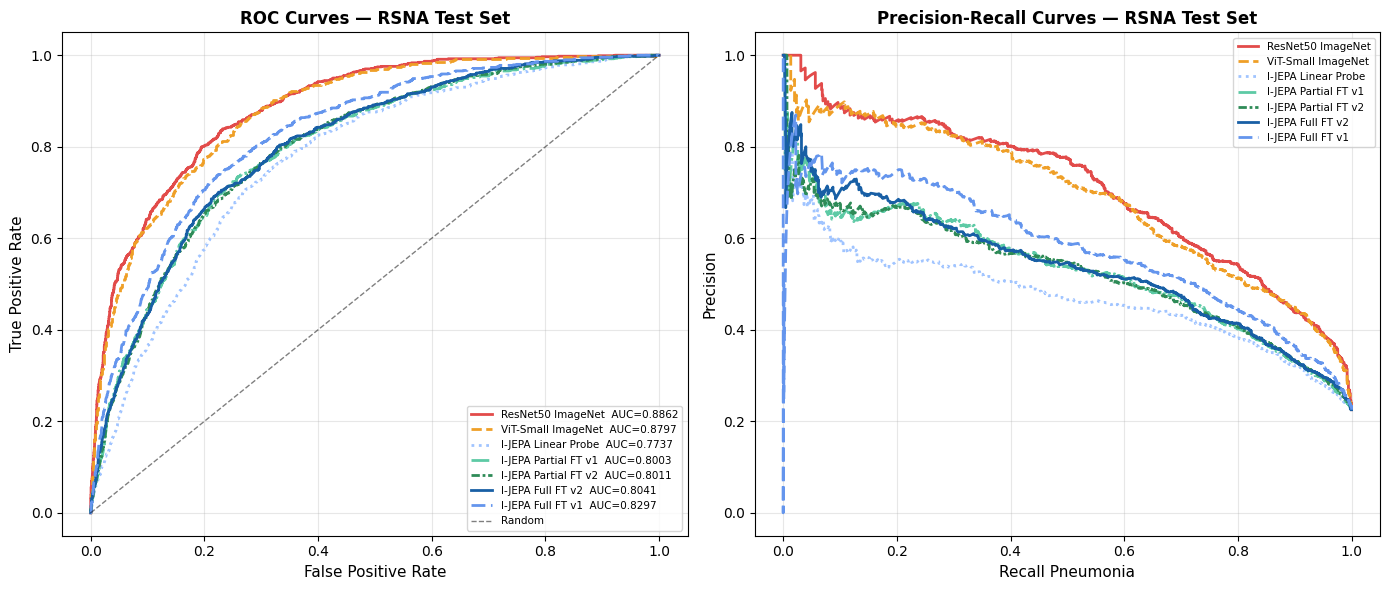

Saved: roc_pr_curves.png


In [8]:
# ============================================================
# CELL 8: ROC CURVE + PRECISION-RECALL CURVE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for model_name, df in predictions.items():
    y_true = df["label"].values
    y_prob = df["prob_pneumonia"].values
    color  = MODEL_COLORS.get(model_name, "gray")
    ls     = MODEL_STYLES.get(model_name, "-")
    auc    = roc_auc_score(y_true, y_prob)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls, lw=2,
                 label=f"{model_name}  AUC={auc:.4f}")

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    axes[1].plot(rec, prec, color=color, linestyle=ls, lw=2, label=model_name)

axes[0].plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Random")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curves — RSNA Test Set", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=7.5, loc="lower right")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Recall Pneumonia", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curves — RSNA Test Set", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=7.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / "roc_pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: roc_pr_curves.png")


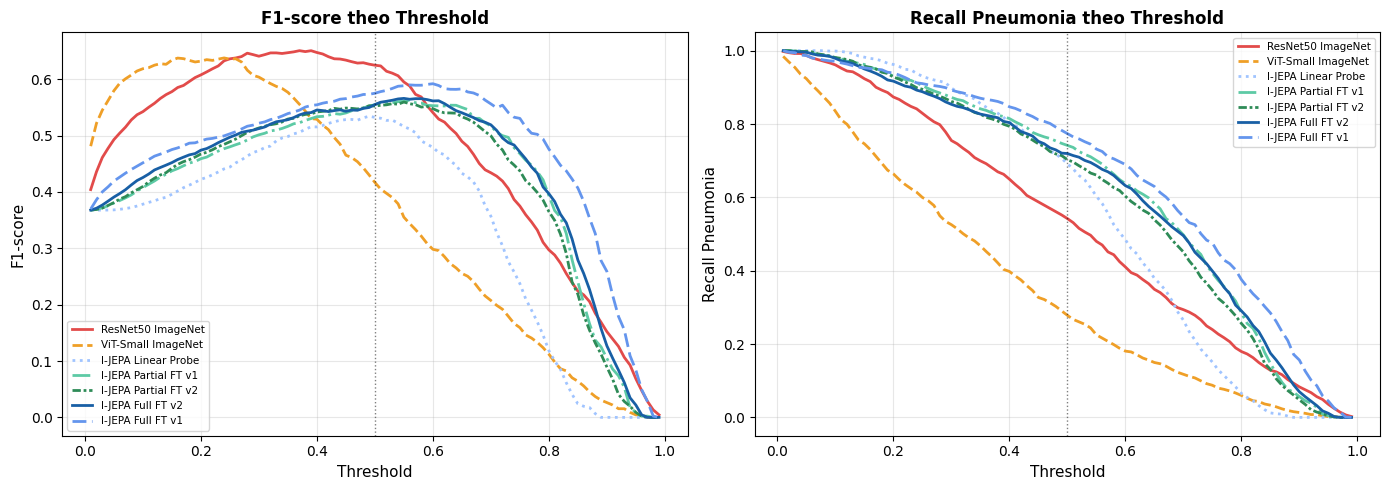

Saved: threshold_curves.png


In [9]:
# ============================================================
# CELL 9: F1 VÀ RECALL THEO THRESHOLD
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, curve_df in threshold_curves.items():
    color = MODEL_COLORS.get(model_name, "gray")
    ls    = MODEL_STYLES.get(model_name, "-")
    axes[0].plot(curve_df["threshold"], curve_df["f1"],
                 color=color, linestyle=ls, lw=2, label=model_name)
    axes[1].plot(curve_df["threshold"], curve_df["recall_pneumonia"],
                 color=color, linestyle=ls, lw=2, label=model_name)

for ax, ylabel, title in zip(axes,
    ["F1-score", "Recall Pneumonia"],
    ["F1-score theo Threshold", "Recall Pneumonia theo Threshold"]):
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=0.5, color="black", linestyle=":", lw=1, alpha=0.5)

plt.tight_layout()
fig.savefig(FIG_DIR / "threshold_curves.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: threshold_curves.png")


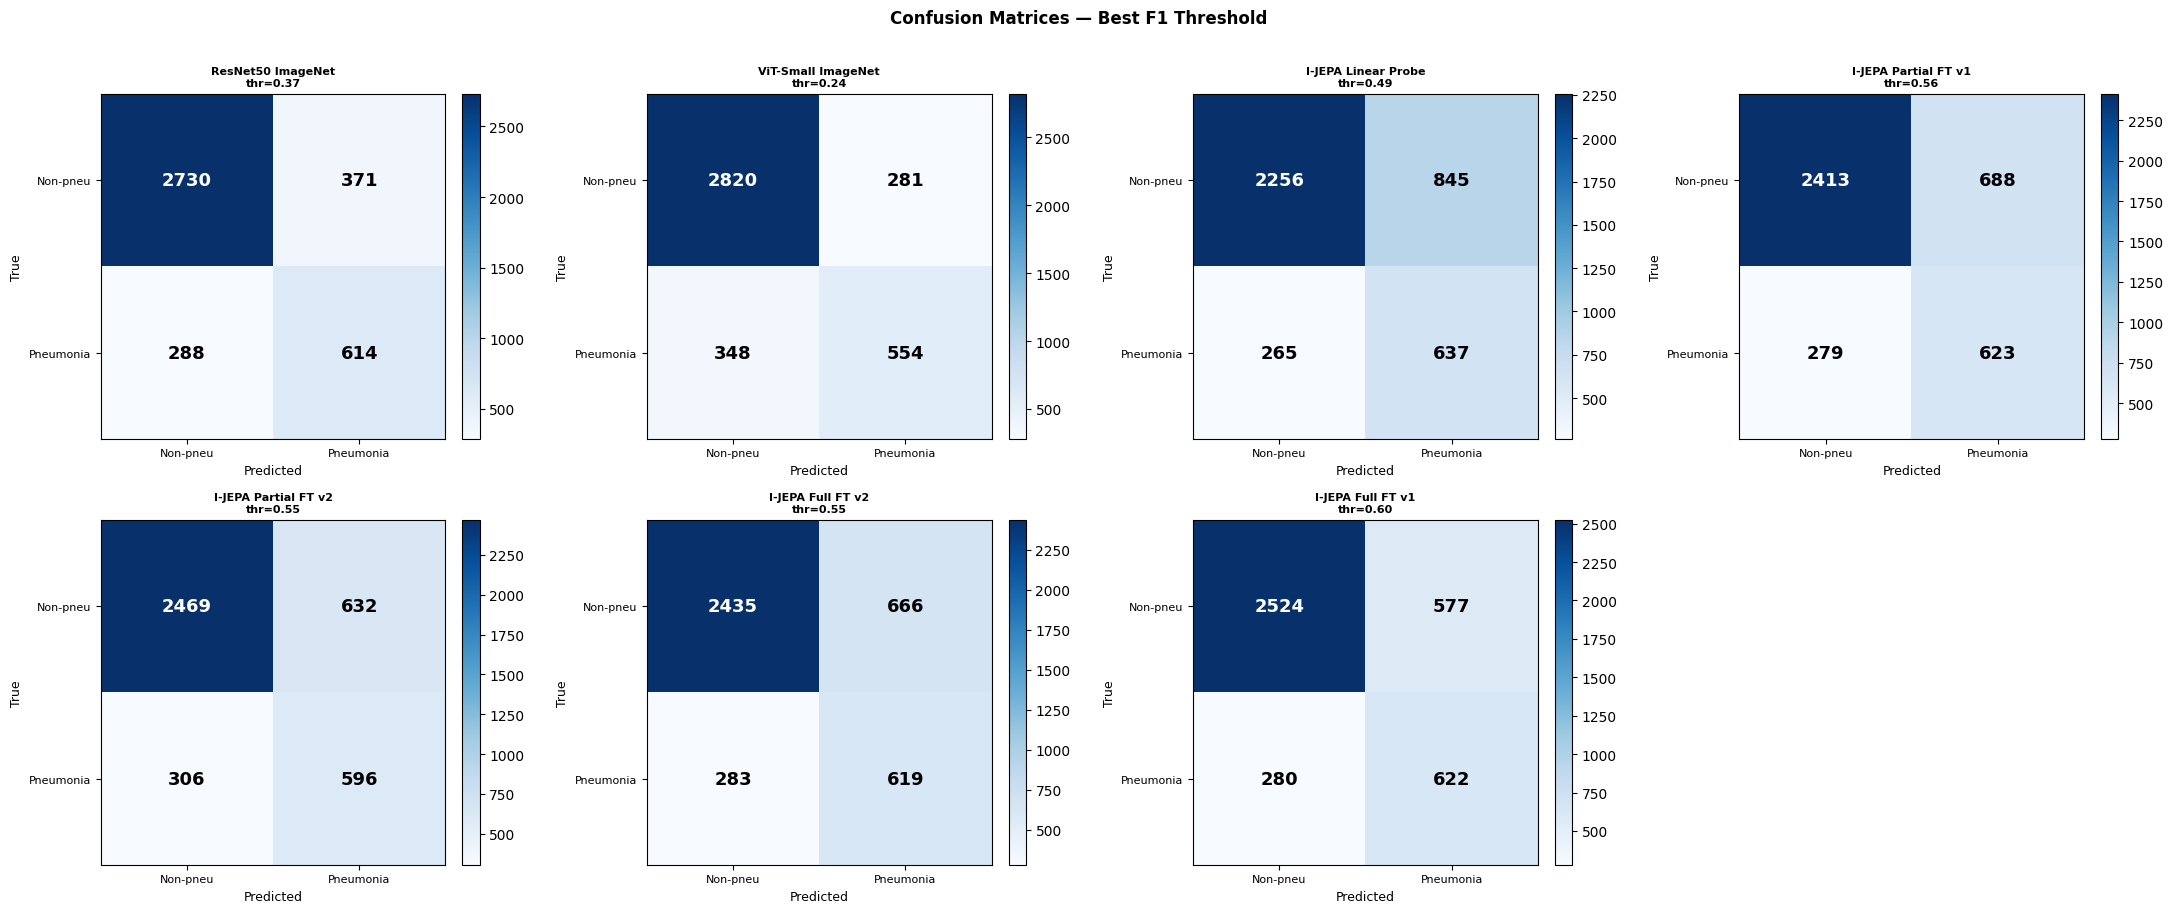

Saved: confusion_matrices.png


In [10]:
# ============================================================
# CELL 10: CONFUSION MATRIX TẤT CẢ MODELS (BEST F1 THRESHOLD)
# ============================================================
best_f1_thresh = {row["model"]: row["threshold"] for _, row in best_f1_df.iterrows()}

n_models = len(predictions)
ncols    = min(4, n_models)
nrows    = math.ceil(n_models / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows))
axes = np.array(axes).flatten()

for ax_idx, (model_name, df) in enumerate(predictions.items()):
    t      = best_f1_thresh.get(model_name, 0.5)
    y_true = df["label"].astype(int).values
    y_pred = (df["prob_pneumonia"].values >= t).astype(int)
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])

    ax = axes[ax_idx]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Non-pneu","Pneumonia"], fontsize=8)
    ax.set_yticklabels(["Non-pneu","Pneumonia"], fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9); ax.set_ylabel("True", fontsize=9)
    ax.set_title(f"{model_name}\nthr={t:.2f}", fontsize=8, fontweight="bold")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                    fontsize=13, fontweight="bold",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices — Best F1 Threshold", fontsize=12,
             fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")


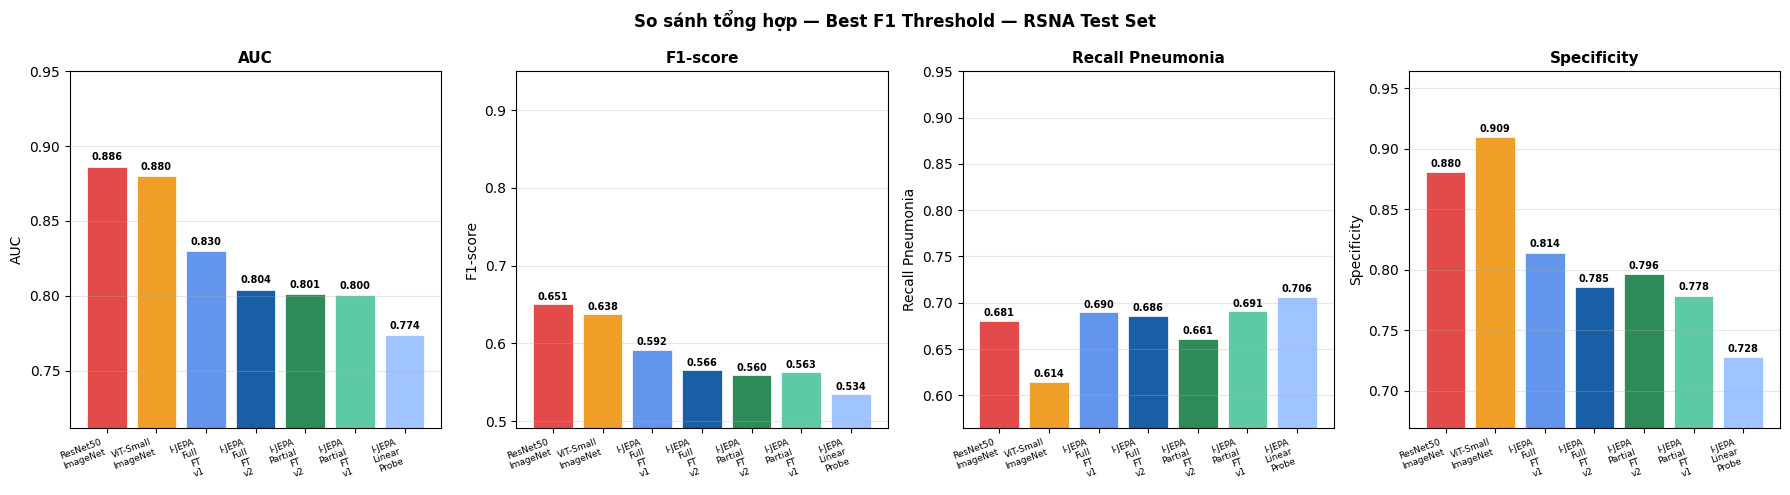

Saved: main_comparison_bar.png


In [11]:
# ============================================================
# CELL 11: BAR CHART SO SÁNH TỔNG HỢP
# ============================================================
metrics_to_plot = ["auc","f1","recall_pneumonia","specificity"]
metric_labels   = ["AUC","F1-score","Recall Pneumonia","Specificity"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax_idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax     = axes[ax_idx]
    vals   = [row[metric] for _, row in best_f1_df.iterrows()]
    names  = [row["model"].replace(" ",  "\n") for _, row in best_f1_df.iterrows()]
    colors = [MODEL_COLORS.get(row["model"], "steelblue") for _, row in best_f1_df.iterrows()]

    bars = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(names, fontsize=6.5, rotation=20, ha="right")
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylim(min(vals)*0.92, max(max(vals)*1.06, 0.95))
    ax.grid(True, axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

plt.suptitle("So sánh tổng hợp — Best F1 Threshold — RSNA Test Set",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "main_comparison_bar.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: main_comparison_bar.png")


## Label-Efficiency Experiment

In [12]:
# ============================================================
# CELL 12: LABEL-EFFICIENCY — SETUP + train_quick
# FIX: hỗ trợ cả IJEPAClassifier và ResNet50 (không có .encoder)
# FIX: torch.amp thay torch.cuda.amp
# FIX: gradient flush cuối epoch
# ============================================================
LABEL_FRACTIONS  = [0.10, 0.25, 0.50, 1.00]
LABEL_EFF_SEED   = 42
LABEL_EFF_EPOCHS = 10
MAX_LABEL_EFF_H  = 5.5

def train_quick(model, sub_df, num_epochs=10, lr=1e-4, enc_lr=1e-5,
                wd=0.05, accum=2):
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(DEVICE))

    # FIX: phân biệt IJEPA vs ResNet50/ViT
    if hasattr(model, "encoder") and hasattr(model, "classifier"):
        param_groups = [
            {"params": [p for p in model.encoder.parameters()    if p.requires_grad], "lr": enc_lr},
            {"params": [p for p in model.classifier.parameters() if p.requires_grad], "lr": lr},
        ]
    else:
        param_groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": lr}]

    optimizer = torch.optim.AdamW(param_groups, weight_decay=wd)
    # FIX: torch.amp.GradScaler
    scaler    = torch.amp.GradScaler(_AMP_DEVICE, enabled=torch.cuda.is_available())
    loader    = DataLoader(RSNADataset(sub_df, train_transform),
                           batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader= DataLoader(RSNADataset(val_df, eval_transform),
                           batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    best_auc = -1
    for epoch in range(num_epochs):
        model.train(); optimizer.zero_grad(set_to_none=True)
        for step, (imgs, labels) in enumerate(loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            # FIX: torch.amp.autocast
            with torch.amp.autocast(_AMP_DEVICE, enabled=torch.cuda.is_available()):
                logits = model(imgs)
                logits = logits.squeeze(-1) if logits.dim() > 1 else logits
                loss   = criterion(logits, labels) / accum
            scaler.scale(loss).backward()
            if (step + 1) % accum == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)
        # FIX: gradient flush cuối epoch
        if (step + 1) % accum != 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
        auc = quick_evaluate_auc(model, val_loader)
        if auc > best_auc:
            best_auc = auc
    return best_auc

print("train_quick() ✓  (hỗ trợ IJEPA + ResNet50, torch.amp)")
print(f"Label fractions: {LABEL_FRACTIONS}")
print(f"Epochs/run: {LABEL_EFF_EPOCHS} | Max wall time: {MAX_LABEL_EFF_H}h")


train_quick() ✓  (hỗ trợ IJEPA + ResNet50, torch.amp)
Label fractions: [0.1, 0.25, 0.5, 1.0]
Epochs/run: 10 | Max wall time: 5.5h


In [13]:
# ============================================================
# CELL 13: CHẠY LABEL-EFFICIENCY EXPERIMENT
# I-JEPA Full FT v2 (best generalization) + ResNet50 baseline
# ============================================================
label_eff_results = []
le_start = time.time()

# Tính RSNA AUC 100% baseline cho ResNet50 từ predictions sẵn có
baseline_100_auc = {}
for name in ["ResNet50 ImageNet", "ViT-Small ImageNet"]:
    if name in predictions:
        baseline_100_auc[name] = RSNA_AUC_FROM_PRED[name]
        print(f"Baseline 100% — {name}: {baseline_100_auc[name]:.4f}")

test_loader_le = DataLoader(RSNADataset(test_df, eval_transform),
                             batch_size=16, shuffle=False,
                             num_workers=2, pin_memory=True)

for frac in LABEL_FRACTIONS:
    elapsed_h = (time.time() - le_start) / 3600
    if elapsed_h > MAX_LABEL_EFF_H:
        print(f"⏱ Time limit {MAX_LABEL_EFF_H}h. Dừng tại frac={frac}.")
        break

    set_seed(LABEL_EFF_SEED)
    pos_df = train_df[train_df["label"]==1].sample(frac=frac, random_state=LABEL_EFF_SEED)
    neg_df = train_df[train_df["label"]==0].sample(frac=frac, random_state=LABEL_EFF_SEED)
    sub_df = pd.concat([pos_df, neg_df]).sample(
        frac=1, random_state=LABEL_EFF_SEED).reset_index(drop=True)
    print(f"\n=== {int(frac*100)}% labels — {len(sub_df):,} samples ===")

    # ── I-JEPA Full FT v2 ──────────────────────────────
    if IJEPA_FULL_V2_CKPT:
        model_ije = make_ijepa_full_v2()
        for p in model_ije.parameters(): p.requires_grad = True
        val_auc  = train_quick(model_ije, sub_df, num_epochs=LABEL_EFF_EPOCHS)
        test_auc = quick_evaluate_auc(model_ije, test_loader_le)
        label_eff_results.append({
            "model": "I-JEPA Full FT v2", "fraction": frac,
            "n_train": len(sub_df), "val_auc": val_auc, "test_auc": test_auc
        })
        print(f"  I-JEPA Full FT v2  val={val_auc:.4f}  test={test_auc:.4f}")
        del model_ije; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── ResNet50 baseline ──────────────────────────────
    import torchvision.models as tvm
    _r50 = tvm.resnet50(weights="IMAGENET1K_V1")
    _r50.fc = nn.Linear(_r50.fc.in_features, 1)
    _r50 = _r50.to(DEVICE)
    val_auc_r50  = train_quick(_r50, sub_df, num_epochs=LABEL_EFF_EPOCHS,
                                lr=1e-4, enc_lr=None, wd=0.05)
    test_auc_r50 = quick_evaluate_auc(_r50, test_loader_le)
    label_eff_results.append({
        "model": "ResNet50 ImageNet", "fraction": frac,
        "n_train": len(sub_df), "val_auc": val_auc_r50, "test_auc": test_auc_r50
    })
    print(f"  ResNet50 ImageNet  val={val_auc_r50:.4f}  test={test_auc_r50:.4f}")
    del _r50; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

label_eff_df = pd.DataFrame(label_eff_results)
label_eff_df.to_csv(TABLE_DIR / "label_efficiency_results.csv", index=False)
display(label_eff_df.round(4))
print("Saved: label_efficiency_results.csv")


Baseline 100% — ResNet50 ImageNet: 0.8862
Baseline 100% — ViT-Small ImageNet: 0.8797

=== 10% labels — 1,868 samples ===
Loading I-JEPA Full FT v2...


  Loaded: ijepa_full_finetune_v2_best.pth | epoch=10 | best_auc=0.8090872267082144


  I-JEPA Full FT v2  val=0.7915  test=0.7861


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

...

  Loaded: ijepa_full_finetune_v2_best.pth | epoch=10 | best_auc=0.8090872267082144


  I-JEPA Full FT v2  val=0.8227  test=0.8136


  ResNet50 ImageNet  val=0.8889  test=0.8816


,model,fraction,n_train,val_auc,test_auc
0,I-JEPA Full FT v2,0.10,1868,0.7915,0.7861
1,ResNet50 ImageNet,0.10,1868,0.8540,0.8354
2,I-JEPA Full FT v2,0.25,4670,0.8099,0.7930
3,ResNet50 ImageNet,0.25,4670,0.8677,0.8331
4,I-JEPA Full FT v2,0.50,9339,0.8173,0.8039
5,ResNet50 ImageNet,0.50,9339,0.8816,0.8614
6,I-JEPA Full FT v2,1.00,18678,0.8227,0.8136
7,ResNet50 ImageNet,1.00,18678,0.8889,0.8816


Saved: label_efficiency_results.csv


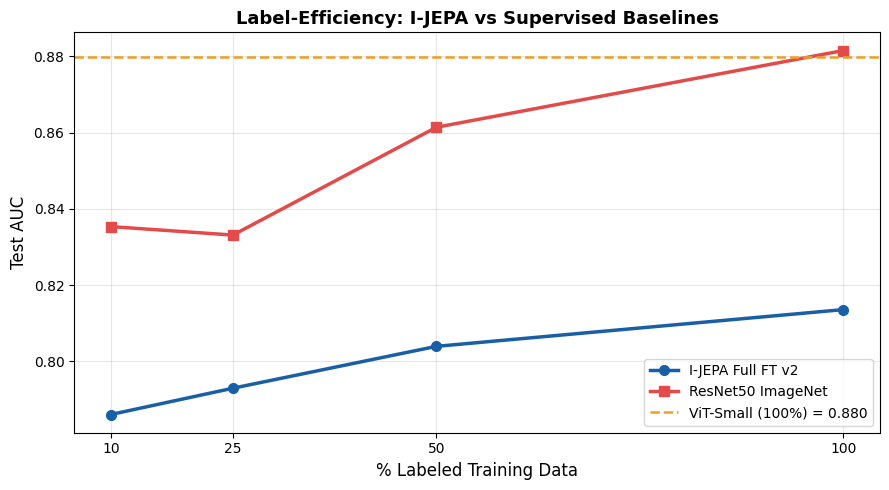

Saved: label_efficiency.png


In [14]:
# ============================================================
# CELL 14: VẼ LABEL-EFFICIENCY CHART
# ============================================================
le_df = pd.read_csv(TABLE_DIR / "label_efficiency_results.csv")

fig, ax = plt.subplots(figsize=(9, 5))

# I-JEPA Full FT v2 — đường theo fraction
ijepa_le = le_df[le_df["model"]=="I-JEPA Full FT v2"].sort_values("fraction")
if len(ijepa_le):
    ax.plot(ijepa_le["fraction"]*100, ijepa_le["test_auc"],
            marker="o", color="#185FA5", lw=2.5, markersize=7,
            label="I-JEPA Full FT v2")

# ResNet50 — đường theo fraction (nếu đủ data)
r50_le = le_df[le_df["model"]=="ResNet50 ImageNet"].sort_values("fraction")
if len(r50_le) >= 2:
    ax.plot(r50_le["fraction"]*100, r50_le["test_auc"],
            marker="s", color="#E24B4A", lw=2.5, markersize=7,
            label="ResNet50 ImageNet")
elif "ResNet50 ImageNet" in baseline_100_auc:
    ax.axhline(baseline_100_auc["ResNet50 ImageNet"],
               color="#E24B4A", linestyle="--", lw=1.8,
               label=f"ResNet50 (100%) = {baseline_100_auc['ResNet50 ImageNet']:.3f}")

# ViT baseline ngang
if "ViT-Small ImageNet" in baseline_100_auc:
    ax.axhline(baseline_100_auc["ViT-Small ImageNet"],
               color="#EF9F27", linestyle="--", lw=1.8,
               label=f"ViT-Small (100%) = {baseline_100_auc['ViT-Small ImageNet']:.3f}")

ax.set_xlabel("% Labeled Training Data", fontsize=12)
ax.set_ylabel("Test AUC", fontsize=12)
ax.set_title("Label-Efficiency: I-JEPA vs Supervised Baselines", fontsize=13,
             fontweight="bold")
ax.set_xticks([10, 25, 50, 100])
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "label_efficiency.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: label_efficiency.png")


## External Validation — VinDr-CXR

In [15]:
# ============================================================
# CELL 15: FIX VINDR LABEL + EXTERNAL VALIDATION
# Tích hợp sẵn mapping fix — không cần chạy cell riêng
# ============================================================

if VINDR_CSV is None:
    print("vindr_external_test.csv not found — skip VinDr validation.")
    vindr_results_df = pd.DataFrame()
else:
    # ── Fix label mapping ──────────────────────────────
    _vdf_raw = pd.read_csv(VINDR_CSV)
    if _vdf_raw["label"].sum() == 0:
        print("Phát hiện label toàn 0 — áp dụng fix mapping từ annotation gốc...")
        VINDR_ANN = None
        for _p in Path("/kaggle/input").rglob("train.csv"):
            _tmp = pd.read_csv(_p, nrows=2)
            if "class_name" in _tmp.columns and "image_id" in _tmp.columns:
                VINDR_ANN = _p; break
        if VINDR_ANN:
            _ann = pd.read_csv(VINDR_ANN)
            _PNEUMONIA_CLASSES = {"Lung Opacity", "Consolidation", "Infiltration"}
            _pneumonia_ids = set(
                _ann[_ann["class_name"].isin(_PNEUMONIA_CLASSES)]["image_id"].unique()
            )
            _vdf_raw["label"] = _vdf_raw["image_id"].apply(
                lambda x: 1 if x in _pneumonia_ids else 0
            )
            _fixed_path = Path("/kaggle/working/vindr_external_test_fixed.csv")
            _vdf_raw.to_csv(_fixed_path, index=False)
            VINDR_CSV = _fixed_path
            print(f"  Fix done: pos={_vdf_raw['label'].sum()} | neg={(_vdf_raw['label']==0).sum()}")
        else:
            print("  Không tìm thấy annotation gốc — không thể fix label.")

    vindr_df = fix_df_paths(pd.read_csv(VINDR_CSV))
    print(f"VinDr: {len(vindr_df):,} samples | "
          f"pos={vindr_df['label'].sum()} | neg={(vindr_df['label']==0).sum()}")
    assert vindr_df["label"].sum() > 0, "VinDr label vẫn toàn 0 — kiểm tra lại dataset"

    vindr_loader = DataLoader(RSNADataset(vindr_df, eval_transform),
                              batch_size=16, shuffle=False,
                              num_workers=2, pin_memory=True)
    vindr_results = []

    @torch.no_grad()
    def infer_vindr(model, desc="inference"):
        model.eval()
        probs, lbls = [], []
        for imgs, labels in tqdm(vindr_loader, desc=desc, leave=False):
            imgs = imgs.to(DEVICE)
            with torch.amp.autocast(_AMP_DEVICE, enabled=torch.cuda.is_available()):
                logits = model(imgs)
            logits = logits.squeeze(-1) if logits.dim() > 1 else logits
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            lbls.extend(labels.numpy())
        return roc_auc_score(np.array(lbls).astype(int), np.array(probs))

    def run_vindr(model_name, model_fn, ckpt_flag):
        if not ckpt_flag:
            print(f"{model_name}: checkpoint not found — skip")
            rsna_auc = RSNA_AUC_FROM_PRED.get(model_name, np.nan)
            vindr_results.append({
                "model": model_name,
                "rsna_test_auc": _safe_round(rsna_auc),
                "vindr_test_auc": None, "drop": None,
                "note": "checkpoint not found"
            })
            return
        m = model_fn()
        vindr_auc = infer_vindr(m, f"{model_name} VinDr")
        rsna_auc  = RSNA_AUC_FROM_PRED.get(model_name, np.nan)
        drop = rsna_auc - vindr_auc if not np.isnan(rsna_auc) else np.nan
        vindr_results.append({
            "model":          model_name,
            "rsna_test_auc":  _safe_round(rsna_auc),
            "vindr_test_auc": _safe_round(vindr_auc),
            "drop":           _safe_round(drop),
            "note":           "checkpoint"
        })
        print(f"{model_name:30s}  RSNA={rsna_auc:.4f} → VinDr={vindr_auc:.4f}  "
              f"(drop={drop:+.4f})")
        del m; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── Chạy tất cả 4 I-JEPA models ──────────────────
    run_vindr("I-JEPA Linear Probe",  make_ijepa_linear,     IJEPA_LINEAR_CKPT)
    run_vindr("I-JEPA Partial FT v1", make_ijepa_partial_v1, IJEPA_PARTIAL_V1_CKPT)
    run_vindr("I-JEPA Partial FT v2", make_ijepa_partial_v2, IJEPA_PARTIAL_V2_CKPT)
    run_vindr("I-JEPA Full FT v1",    make_ijepa_full_v1,    IJEPA_FULL_V1_CKPT)
    run_vindr("I-JEPA Full FT v2",    make_ijepa_full_v2,    IJEPA_FULL_V2_CKPT)

    # ── ResNet50 ──────────────────────────────────────
    if RESNET50_CKPT:
        import torchvision.models as tvm
        _r50 = tvm.resnet50(weights=None)
        _r50.fc = nn.Linear(_r50.fc.in_features, 1)
        try:    ck = torch.load(RESNET50_CKPT, map_location=DEVICE, weights_only=False)
        except TypeError: ck = torch.load(RESNET50_CKPT, map_location=DEVICE)
        _r50.load_state_dict(ck.get("model_state_dict", ck), strict=False)
        _r50 = _r50.to(DEVICE)
        vindr_auc = infer_vindr(_r50, "ResNet50 VinDr")
        rsna_auc  = RSNA_AUC_FROM_PRED.get("ResNet50 ImageNet", np.nan)
        drop = rsna_auc - vindr_auc if not np.isnan(rsna_auc) else np.nan
        vindr_results.append({
            "model": "ResNet50 ImageNet",
            "rsna_test_auc": _safe_round(rsna_auc),
            "vindr_test_auc": _safe_round(vindr_auc),
            "drop": _safe_round(drop), "note": "checkpoint"
        })
        print(f"ResNet50 ImageNet              RSNA={rsna_auc:.4f} → VinDr={vindr_auc:.4f}  "
              f"(drop={drop:+.4f})")
        del _r50; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    else:
        rsna_auc = RSNA_AUC_FROM_PRED.get("ResNet50 ImageNet", np.nan)
        vindr_results.append({
            "model": "ResNet50 ImageNet",
            "rsna_test_auc": _safe_round(rsna_auc),
            "vindr_test_auc": None, "drop": None, "note": "checkpoint not found"
        })
        print("ResNet50: checkpoint not found — skipped")

    # ── ViT-Small ─────────────────────────────────────
    if VIT_CKPT:
        _vit = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=1)
        try:    ck = torch.load(VIT_CKPT, map_location=DEVICE, weights_only=False)
        except TypeError: ck = torch.load(VIT_CKPT, map_location=DEVICE)
        _vit.load_state_dict(ck.get("model_state_dict", ck), strict=False)
        _vit = _vit.to(DEVICE)
        vindr_auc = infer_vindr(_vit, "ViT VinDr")
        rsna_auc  = RSNA_AUC_FROM_PRED.get("ViT-Small ImageNet", np.nan)
        drop = rsna_auc - vindr_auc if not np.isnan(rsna_auc) else np.nan
        vindr_results.append({
            "model": "ViT-Small ImageNet",
            "rsna_test_auc": _safe_round(rsna_auc),
            "vindr_test_auc": _safe_round(vindr_auc),
            "drop": _safe_round(drop), "note": "checkpoint"
        })
        print(f"ViT-Small ImageNet             RSNA={rsna_auc:.4f} → VinDr={vindr_auc:.4f}  "
              f"(drop={drop:+.4f})")
        del _vit; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    else:
        rsna_auc = RSNA_AUC_FROM_PRED.get("ViT-Small ImageNet", np.nan)
        vindr_results.append({
            "model": "ViT-Small ImageNet",
            "rsna_test_auc": _safe_round(rsna_auc),
            "vindr_test_auc": None, "drop": None, "note": "checkpoint not found"
        })
        print("ViT-Small: checkpoint not found — skipped")

    vindr_results_df = pd.DataFrame(vindr_results)
    vindr_results_df.to_csv(TABLE_DIR / "vindr_external_validation.csv", index=False)
    print("\n=== VinDr External Validation ===")
    display(vindr_results_df.round(4))
    print("Saved: vindr_external_validation.csv")


VinDr: 12,194 samples | pos=1588 | neg=10606
Loading I-JEPA Linear Probe...


  Loaded: ijepa_linear_probe_best.pth | epoch=15 | best_auc=0.7820324392889498


I-JEPA Linear Probe VinDr:   0%|          | 0/763 [00:00<?, ?it/s]

I-JEPA Linear Probe             RSNA=0.7737 → VinDr=0.5570  (drop=+0.2168)


Loading I-JEPA Partial FT v1...


...

Loading I-JEPA Full FT v2...


  Loaded: ijepa_full_finetune_v2_best.pth | epoch=10 | best_auc=0.8090872267082144


I-JEPA Full FT v2 VinDr:   0%|          | 0/763 [00:00<?, ?it/s]

I-JEPA Full FT v2               RSNA=0.8041 → VinDr=0.4346  (drop=+0.3695)


ResNet50 VinDr:   0%|          | 0/763 [00:00<?, ?it/s]

## Bảng Tổng Hợp Cuối

In [ ]:
# ============================================================
# CELL 16: BẢNG TỔNG HỢP CHO LUẬN VĂN + PAPER
# ============================================================
cols_show = ["model","auc","f1","recall_pneumonia","specificity","precision","threshold"]

print("=" * 70)
print("BẢNG 1: Main Comparison (Best F1 Threshold) — RSNA Test Set")
print("=" * 70)
display(best_f1_df[cols_show].round(4))

print("\n" + "=" * 70)
print("BẢNG 2: Threshold Tuning — I-JEPA Full FT v2")
print("=" * 70)
for _model_name in ["I-JEPA Full FT v2", "I-JEPA Full FT v1"]:
    if _model_name in threshold_summary_df["model"].values:
        _t = threshold_summary_df[threshold_summary_df["model"]==_model_name]
        display(_t[["threshold_type","threshold","auc","f1",
                     "recall_pneumonia","specificity"]].round(4))
        break

print("\n" + "=" * 70)
print("BẢNG 3: Label-Efficiency — Test AUC")
print("=" * 70)
_le_path = TABLE_DIR / "label_efficiency_results.csv"
if _le_path.exists():
    display(pd.read_csv(_le_path)[["model","fraction","n_train","test_auc"]].round(4))

_vindr_path = TABLE_DIR / "vindr_external_validation.csv"
if _vindr_path.exists() and pd.read_csv(_vindr_path)["vindr_test_auc"].notna().any():
    print("\n" + "=" * 70)
    print("BẢNG 4: External Validation — VinDr-CXR")
    print("=" * 70)
    display(pd.read_csv(_vindr_path).round(4))

# Lưu JSON
_empty_metrics = {"auc":None,"f1":None,"recall_pneumonia":None,
                  "specificity":None,"precision":None,"accuracy":None}
linear_test_metrics  = locals().get("linear_test_metrics",  _empty_metrics.copy())
partial_test_metrics = locals().get("partial_test_metrics", _empty_metrics.copy())
full_test_metrics    = locals().get("full_test_metrics",     None)

summary_all = {
    "main_comparison": best_f1_df[cols_show].to_dict("records"),
    "threshold_tuning": threshold_summary_df[
        threshold_summary_df["model"].isin(["I-JEPA Full FT v2","I-JEPA Full FT v1"])
    ].head(8)[["threshold_type","threshold","auc","f1","recall_pneumonia","specificity"]].to_dict("records"),
    "label_efficiency": pd.read_csv(_le_path).to_dict("records") if _le_path.exists() else [],
    "vindr_validation": pd.read_csv(_vindr_path).to_dict("records") if _vindr_path.exists() else [],
}
with open(OUTPUT_DIR / "final_summary.json", "w") as f:
    json.dump(summary_all, f, indent=2, ensure_ascii=False)
print("\nSaved: final_summary.json ✓")


In [ ]:
# ============================================================
# CELL 17: NÉN OUTPUT
# ============================================================
print("Files trong output:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(OUTPUT_DIR)):55s}  ({p.stat().st_size/1e3:6.1f} KB)")

shutil.make_archive("/kaggle/working/notebook05_evaluation_v3", "zip", OUTPUT_DIR)
print("\nCreated: notebook05_evaluation_v3.zip")
print(f"Tổng thời gian: {(time.time()-NOTEBOOK_START_TIME)/3600:.2f}h")
